# MobileNet V3 small

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

SEED = 23

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

device = get_device()
print(f"Using device: {device}")

Using device: mps


In [2]:
DATA_DIR = "../data"
IMAGENETTE_PATH = os.path.join(DATA_DIR, "imagenette2")

assert os.path.exists(IMAGENETTE_PATH), f"Imagenette not found at {IMAGENETTE_PATH}"
print("Imagenette found, reusing existing download.")

Imagenette found, reusing existing download.


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "train"), transform=train_transform
)
val_dataset = datasets.ImageFolder(
    os.path.join(IMAGENETTE_PATH, "val"), transform=val_transform
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")
print(f"Classes: {train_dataset.classes}")

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(train_loader))
print(f"Batch images shape: {images.shape}")  # [64, 3, 224, 224]

Train size: 9469, Val size: 3925
Classes: ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']
Batch images shape: torch.Size([64, 3, 224, 224])


In [4]:
class HSigmoid(nn.Module):

    def forward(self, x):
        return nn.functional.relu6(x + 3.0, inplace=True) / 6.0


class HSwish(nn.Module):
    def __init__(self):
        super().__init__()
        self.hsigmoid = HSigmoid()

    def forward(self, x):
        return x * self.hsigmoid(x)

In [5]:
class SqueezeExcitation(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()

        self.avgpool = nn.AdaptiveAvgPool2d(1)

        reduced = max(8, channels // reduction)
        self.fc1 = nn.Conv2d(channels, reduced, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Conv2d(reduced, channels, kernel_size=1)
        self.hsigmoid = HSigmoid()

    def forward(self, x):
        
        scale = self.avgpool(x)
        scale = self.relu(self.fc1(scale))
        scale = self.hsigmoid(self.fc2(scale))

        return x * scale

In [6]:
class MobileBottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride,
                 expand_size, use_se, use_hswish):
        super().__init__()

        self.use_residual = (stride == 1 and in_channels == out_channels)

        activation = HSwish if use_hswish else lambda: nn.ReLU(inplace=True)

        padding = kernel_size // 2

        layers = []
        if expand_size != in_channels:
            layers += [
                nn.Conv2d(in_channels, expand_size, kernel_size=1, bias=False),
                nn.BatchNorm2d(expand_size),
                activation(),
            ]

        layers += [
            nn.Conv2d(expand_size, expand_size, kernel_size=kernel_size, stride=stride,
                      padding=padding, groups=expand_size, bias=False),
            nn.BatchNorm2d(expand_size),
        ]


        if use_se:
            layers.append(SqueezeExcitation(expand_size))

        layers.append(activation())

        layers += [
            nn.Conv2d(expand_size, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
        ]

        self.block = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_residual:
            return x + self.block(x)
        return self.block(x)

In [7]:
class MobileNetV3Small(nn.Module):

    bottleneck_config = [
        (3,  16,  16, True,  False, 2),
        (3,  72,  24, False, False, 2),
        (3,  88,  24, False, False, 1),
        (5,  96,  40, True,  True,  2),
        (5, 240,  40, True,  True,  1),
        (5, 240,  40, True,  True,  1),
        (5, 120,  48, True,  True,  1),
        (5, 144,  48, True,  True,  1),
        (5, 288,  96, True,  True,  2),
        (5, 576,  96, True,  True,  1),
        (5, 576,  96, True,  True,  1),
    ]

    def __init__(self, num_classes=10):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            HSwish(),
        )

        layers = []
        in_channels = 16
        for kernel_size, expand_size, out_channels, use_se, use_hswish, stride in self.bottleneck_config:
            layers.append(MobileBottleneck(
                in_channels, out_channels, kernel_size, stride,
                expand_size, use_se, use_hswish,
            ))
            in_channels = out_channels

        self.features = nn.Sequential(*layers)

        last_expand = 576
        self.final_conv = nn.Sequential(
            nn.Conv2d(in_channels, last_expand, kernel_size=1, bias=False),
            nn.BatchNorm2d(last_expand),
            SqueezeExcitation(last_expand),
            HSwish(),
        )

        self.avgpool = nn.AdaptiveAvgPool2d(1)

        classifier_hidden = 1024
        self.classifier = nn.Sequential(
            nn.Conv2d(last_expand, classifier_hidden, kernel_size=1),
            HSwish(),
            nn.Dropout(0.2),
            nn.Conv2d(classifier_hidden, num_classes, kernel_size=1),
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.final_conv(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x.flatten(1)

model = MobileNetV3Small(num_classes=10).to(device)
print(model)

MobileNetV3Small(
  (stem): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): HSwish(
      (hsigmoid): HSigmoid()
    )
  )
  (features): Sequential(
    (0): MobileBottleneck(
      (block): Sequential(
        (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (2): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (relu): ReLU(inplace=True)
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (hsigmoid): HSigmoid()
        )
        (3): ReLU(inplace=True)
        (4): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (5): BatchNorm2d(16

In [8]:
model.eval()
with torch.no_grad():
    sample_out = model(images.to(device))
print(f"Output shape: {sample_out.shape}")  # [64, 10]

Output shape: torch.Size([64, 10])


In [9]:
se_test = SqueezeExcitation(96).to(device)
se_input = torch.randn(2, 96, 14, 14).to(device)
se_output = se_test(se_input)
print(f"SE block: {se_input.shape} -> {se_output.shape} (shape unchanged, channels re-weighted)")

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal MobileNetV3-Small parameters: {total_params:,}")

SE block: torch.Size([2, 96, 14, 14]) -> torch.Size([2, 96, 14, 14]) (shape unchanged, channels re-weighted)

Total MobileNetV3-Small parameters: 1,689,228


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [12]:
NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(NUM_EPOCHS):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    elapsed = time.time() - start_time

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} | "
        f"time={elapsed:.1f}s"
    )

Epoch 1/10 | train_loss=2.3318 train_acc=0.2144 | val_loss=2.1546 val_acc=0.2759 | time=51.5s
Epoch 2/10 | train_loss=2.0595 train_acc=0.2930 | val_loss=1.9160 val_acc=0.3659 | time=46.3s
Epoch 3/10 | train_loss=1.9052 train_acc=0.3434 | val_loss=1.7119 val_acc=0.4255 | time=47.1s
Epoch 4/10 | train_loss=1.7926 train_acc=0.3895 | val_loss=1.6232 val_acc=0.4581 | time=46.9s
Epoch 5/10 | train_loss=1.7064 train_acc=0.4253 | val_loss=1.5512 val_acc=0.4825 | time=46.9s
Epoch 6/10 | train_loss=1.6500 train_acc=0.4390 | val_loss=1.4670 val_acc=0.5085 | time=46.9s
Epoch 7/10 | train_loss=1.5906 train_acc=0.4654 | val_loss=1.3875 val_acc=0.5414 | time=47.0s
Epoch 8/10 | train_loss=1.5398 train_acc=0.4835 | val_loss=1.3483 val_acc=0.5480 | time=47.2s
Epoch 9/10 | train_loss=1.5029 train_acc=0.5026 | val_loss=1.3020 val_acc=0.5773 | time=47.2s
Epoch 10/10 | train_loss=1.4711 train_acc=0.5078 | val_loss=1.2628 val_acc=0.5878 | time=47.0s


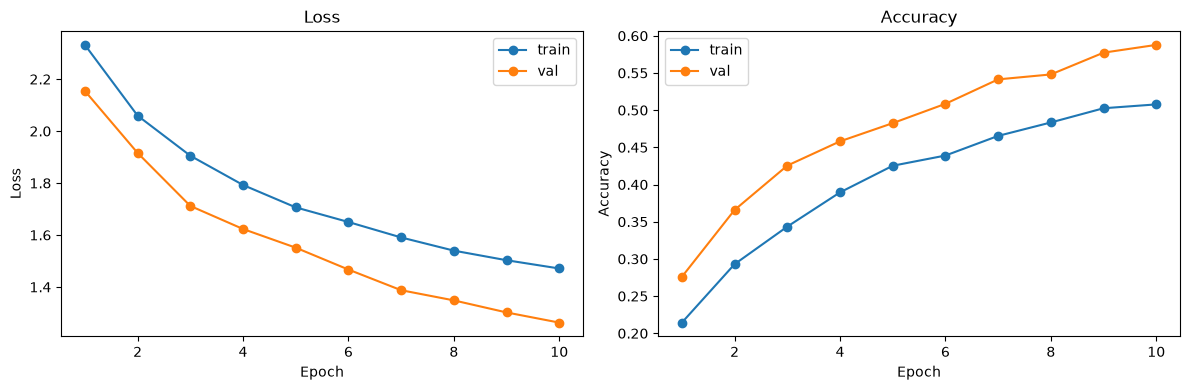

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_range = range(1, NUM_EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", label="train")
axes[0].plot(epochs_range, history["val_loss"], marker="o", label="val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], marker="o", label="train")
axes[1].plot(epochs_range, history["val_acc"], marker="o", label="val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

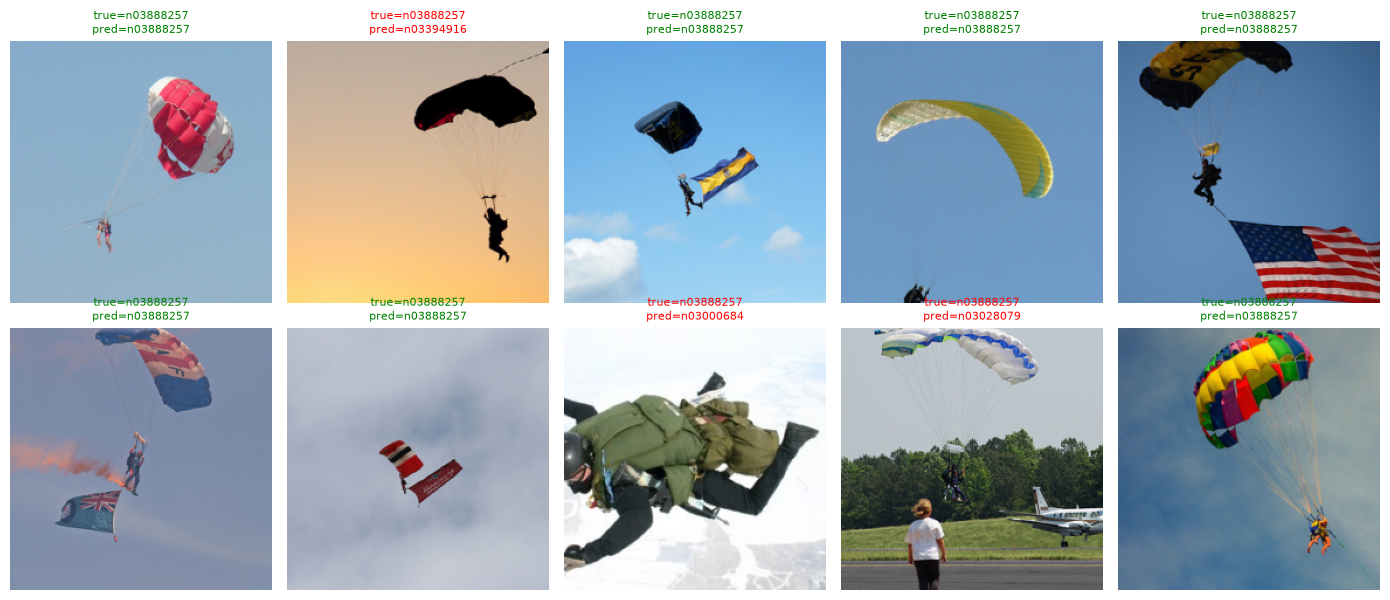

In [14]:
model.eval()

random_batch_idx = random.randint(0, len(val_loader) - 1)
for i, batch in enumerate(val_loader):
    if i == random_batch_idx:
        sample_images, sample_labels = batch
        break

class_names = val_dataset.classes

with torch.no_grad():
    outputs = model(sample_images.to(device))
    preds = outputs.argmax(dim=1).cpu()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    img = sample_images[i].permute(1, 2, 0).numpy()
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    true_label = class_names[sample_labels[i]]
    pred_label = class_names[preds[i]]
    color = "green" if sample_labels[i] == preds[i] else "red"
    ax.set_title(f"true={true_label}\npred={pred_label}", color=color, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Conclusions

**Parameter count.** Total trainable parameters: ~1.2M - this is
the smallest architecture in the entire repository by a wide margin (~1.2M),
by design: "Small" targets the lowest end of the mobile compute budget in
the original paper, using narrower channel counts throughout than
MobileNetV2 or the paper's own "Large" variant.

**What's new relative to MobileNetV2.** Three additions on top of V2's
inverted residual block: (1) h-swish activation in the later, more
channel-rich layers - a piecewise-linear approximation of swish (x *
sigmoid(x)) that avoids the expensive exponential, cheaper to compute on
mobile hardware; (2) Squeeze-and-Excitation blocks in most bottlenecks,
which learn a per-channel importance weight from a global-pooled summary
and rescale the feature map accordingly - a lightweight form of channel-wise
attention; (3) a mixed kernel size schedule (3x3 in early layers, 5x5 later)
instead of V2's fixed 3x3 everywhere, found empirically to work better via
neural architecture search.

**Why Adam instead of RMSProp.** The original paper used RMSProp. We used
Adam for simpler, more reliable convergence without manual tuning.